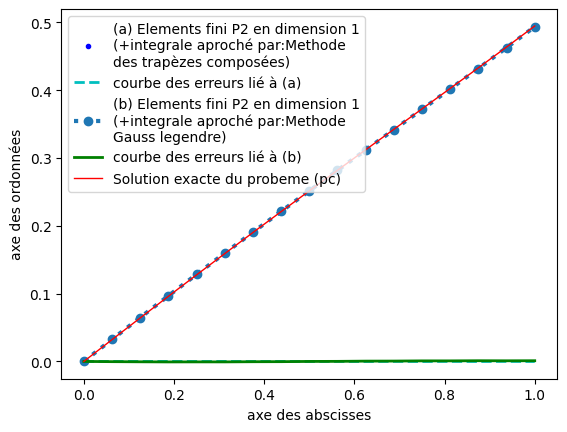

In [34]:
import numpy as np
from matplotlib.pyplot import *
from mpl_toolkits import mplot3d
from math import *
                                 # Matrice orgmenté
def Matrice_orgmente(A, B):
    n = len(B)
    C = np.array([[None] * 1] * n)
    C[:n, 0] = B[0:n]
    A = np.append(A, C, axis=1)
    return(A)
                           # calcule de la norme d'un vecteur
def Norme_vecteur(U, V):
    m = len(U)
    som = 0
    for i in range(0, m):
        som = som + (U[i] - V[i]) ** 2
    Norme = float(sqrt(som))
    return (Norme)
                          # calcule du produit scalaire des vecteurs
def Produit_scalaire(U, V):
    m = len(U)
    som = 0
    for i in range(0, m):
        som = som + U[i] * V[i]
    return (som)
                         # calcule du produit matrice vecteur
def P_Matrice_vecteur(A, V):
    m = len(A)
    U = np.array([0] * m, float)
    for i in range(0, m):
        j = 0
        p = 0
        while (i < m and p < m):
            U[i] = U[i] + (A[i, j] * V[p])
            j = j + 1
            p = p + 1
    return (U)

                # Resolution d'un système linéaire AX=B par la methode  du gradient conjugué
def Grandient_conjugue(A, B, X0, p):
    m = len(A); n = 1                                                             # m=nombre d'élement d'une ligne de la matrice A
    A = Matrice_orgmente(A, B)                                         #ajouter B à la fin de A
    d2 = "oui"                                                                        # A est symetrique definie positive ?
    if (d2 == "oui"):
        Y = np.array([[None] * m] * n, float)                                  # variable solution
        Alpha = np.array([None] * n, float)                                    #variable pas
        D = np.array([[None] * m] * n, float)                                # variable direction selon le pas
        Y[0][0:m] = X0[0:m]                                                           # condition initiale X0 fixé
        (Ad) = P_Matrice_vecteur(A, Y[0])                                    # le vecteur AY0 où AX0
        D[0][0:m] = B - Ad                                                             # le vecteur R0=d0
        (N2) = Norme_vecteur(Ad, B)                                          #initialiation de ||R0||=||B-AX0|| où ||R0||=||B-AY0||
        k = 0
        while (N2 > p):                                                                    # Effecture la boucle jusqu'a ||Rk||=||B-AXk||>precision
            R = B - Ad                                                                       # clacluer le vecteur Rk
            (Q) = P_Matrice_vecteur(A, D[k])                                # le clacluer le vecteur Adk
            (b) = Produit_scalaire(Q, D[k])                                      # le clacluer le produit scalaire Adk.dk
            (a) = Produit_scalaire(R, D[k])                                      # le clacluer le produit scalaire Adk.Rk
            if (b != 0):                                                                       # verifier si la division par b est possible
                c = a / b                                                                      # claculer le pas apha_k
                Alpha = np.append(Alpha, [c], axis=0)  # Ajouter le pas apha_k à toutes les pas à la fin (NB: Alpha[0]=None)
                y = Y[k][0:m] + Alpha[k + 1] * D[k][:m]                  #claculer la nouvelle solution Xk+1
                Y = np.append(Y, [y], axis=0)                # Ajouter comme dermier solutions aprocher Xk+1 à toutes les solution
                (Q) = P_Matrice_vecteur(A, Y[k + 1])                      # claculer le vecteur A.Xk+1
                R = B - Q                                                                    # claculer le nouveau vecteur R=Rk+1
                (Q1) = P_Matrice_vecteur(A, R)                               # claculer le  vecteur A.Rk+1
                (a1) = Produit_scalaire(Q1, D[k])                             # claculer la norme  ||ARk+1-dk||
                d = -a1 / b                                                                  # claculer le coefficient Beta_k
                V = R + d * D[k][:m]                                                 # claculer la direction dk+1(nouvelle direction)
                D = np.append(D, [V], axis=0)               #Ajouter comme dermier direction à toutes les directions
                (Q2) = P_Matrice_vecteur(A, Y[k+ 1])                    # claculer le vecteur A.Xk+1
                (N2) = Norme_vecteur(Q2, B)                                # claculer la nouvelle norme  ||Rk+1||=||B-AXk+1||
                k = k + 1                                                                    #derniere itération+1
            else:
                break
        sol = Y[k]                                                                                                # solution de l'équation AX=B donné avec en k itération
    else:
        sol = ("inconnu. La matrice associeé au syteme peut être non "
               "\nsymetrique  et non definie positive donc le"
               " systeme admet pas de solution par la methode "
               "\ndu grandient à pas optimale puisqu'on ne peut"
               " \n minimiser la fonctionnelle:"
               " \nJ(x)=(1/2)<Ax,x> - <B,x>  avec x dans R^n \n\n"
               "\n Merci de verifier si la matrice A est :\n i) Definie positive"
               "\n 2i) Syemetrique"
               "\n À fini que :"
               " <•,•> soit un produit scalaire et que J(Ū)=min(J(x)), "
               "\n x dans R^n  implique AŪ=B.")                                                  # Affichier cette information losque A n'est à diagonale strictement domimante
    return (sol)

def Choix_pivot_partielle(A, i):
    m = len(A)
    for k in range(i + 1, m):
         if (fabs(A[k, i]) > fabs(A[i, i])):
            x = A[k, :m + 1].copy()
            A[k, :m + 1] = A[i, :m + 1]
            A[i, :m + 1] = x
    return (A)
                                           # fonction écholonnée
def Echelonnée(A):
    m = len(A)
    for i in range(0, m):
        for j in range(i + 1, m):
            if (A[i, i] != 0):
                coef = A[j, i] / A[i, i]
                A[j, :] = A[j, :] - coef * A[i, :]
        for i in range(0, m):
           if (A[i, i] != 0):
             A[i, :] = A[i, :] / A[i, i]
    return (A)

def Calcule_solution(A):
    m = len(A)
    sol = [None] * m
    sol[m - 1] = A[m - 1, m]
    for i in range(m - 2, -1, -1):
        som = 0
        for j in range(i + 1, m):
            som = som + A[i, j] * sol[j]
            sol[i] = A[i, m] - som
            sol = np.array(sol)
    return (sol)

def Gauss_partielle(A, B):
    m = len(A)
    (Mo) = Matrice_orgmente(A, B)
    for i in range(0, m):
        (Mp) = Choix_pivot_partielle(Mo, i)
        (Mp) = Echelonnée(Mp)
        (sol_p) = Calcule_solution(Mp)
    return (sol_p)

        # système linéaire associée à l'approximation d'EDP  u''(x)+beta*u(x)=f(x) sur omega=]a,b[
    # avec u(a)=0 et u'(b)=alpha
def Matrice_associée(beta, alpha, F, a, b, n):                         # Discretisation initiale de omega en  n+1 points
    pas = (b - a) / n                                                                      # Pas constante de la discretisation                                                                           # nombre de solution inconu sur le maillage T
    A = np.array([[0] * 2 * n] * 2 * n, float)                               # matrice associée aux inconu : Ah
    B = np.array([None] * 2 * n, float)                                        # Seconde menbre Bh du système: AhX=Bh
    for i in range(0, 2 * n):
        for j in range(0, 2 * n):
            if (i == j and i < n - 1):
                A[i, i] = 14 / (3 * pas) + (4 * pas * beta) / 15
                A[i, i + 1] = 1 / (3 * pas) - (beta * pas) / 30
                A[i, i + n] = -8 / (3 * pas) +(pas * beta) / 15
                A[i, i + n + 1] = -8 / (3 * pas) +(pas * beta) / 15
            elif (i == j and i > n - 1):
                A[i, i] = 16 / (3 * pas) + (8*beta * pas) / 15
                A[i, i - n] = -8 / (3 * pas) + (pas * beta) / 15
            elif (i == j + 1 and i < n):
                A[i, j] = 1 / (3 * pas) - (beta * pas) / 30
                A[i + n, i - 1] = -8 / (3 * pas) + (pas * beta) / 15
            elif (i == n - 1):
                A[i, i] = 7 / (3 * pas) + (2 * pas * beta) / 15
                A[i, 2 * n - 1] = -8 / (3 * pas) + (pas * beta) / 15
    B[n - 1] =(pas/4)*F[n] + alpha
    for i in range(1, n):
        B[i-1] =(pas /2)*F[i]
        B[i + n-1] =(pas /2)*F[i + n]
    B[2 * n - 1] = (pas/2 )*F[2 * n]
    return (A, B)


def Discretisation_et_fonction_F(a, b, n):
    pas = (b - a) / n                                                        # Pas constante de la discretisation
    x = np.array([None] * (2 * n+1), float)                  # points de discretisation non ordonné
    F = np.array([None] * (2 * n+1), float)                  # la fonction associée au probleme (pc)
    X = np.array([None] * (2 * n + 1), float)                # points totale discretiser ordonné
    x[0] = a                                                                     # valeur du bord inférieur de omega=[a,b]
    F[0]=x[0]* e ** (-x[0])                                            # valeur de F au point x=a
    for i in range(1, n +1):
        x[i] = a + i * pas
        x[i + n ] = (x[i - 1] + x[i]) / 2
        F[i] = x[i] * e ** (-x[i])                                         #clalculer des autres valeurs de F aux point discrétiser
        F[i + n] = x[i + n] * e ** (-x[i + n])
    for i in range(0, n):                                                  # organisations des points discretiser sur le leurs position exacte
         X[2 * i + 1] = x[i + n + 1]
         X[2 * i] = x[i]
    X[2 * n] = x[n]
    return (F, X, x)

def Solution_approché(U0, Ah, Bh, X0,p,n):
    Uap = np.array([None] * (2 * n + 1), float)                     # Uap: solution approcher   # obténu en approchant Bh par la methode des Trapèzes composées
    Uap[0] = U0                                                                       # valeur de la solution initiale
    sol = Grandient_conjugue(Ah, Bh, X0, p)                        # Resolution du sytème AhUh=Bh par gradient conjuguéreturn (Uap)
    for i in range(1, n + 1):                                                       # organisations de la solution approcher en fonction des points associée X
        Uap[2 * i] = sol[i - 1]
        Uap[2 * i - 1] = sol[i + n - 1]
    return (Uap)

def les_poids_omega_i(racine_PL,p):                       #racine_PL=[t1,t2,t3,....,ti,....,t2n-1]  les racines du polynome de legendre P2n-1
    m =len(racine_PL)
    M =np.array([[None]*m]*(2*m+2),float)                  #système à 2m équations et m inconnu
    D =np.array([None]*(2*m+2),float)
    A = np.array([[None] * m] * m, float)                # premier bloc: m équations et m inconnu sachant les racine du polynome PL de legendre
    B = np.array([None] * m, float)
    for i in range(0,2*m+2):
        D[i]=(1-(-1)**(i+1))/(i+1)                                  # intégrale de -1 à 1 des fonction de base (t^0,t^1,....,t^m)
    k=0
    for i in range(0,2*m+2):
        for j in range(0,m):
            M[i,j]=(racine_PL[j])**(k)                           # Coéfficent de la matrice ayant pour incomu les poids d'intégration
        k=k+1
    for i in range(0,m):
        A[i,:m]=M[i,:m]                                                 # matrice non defini positive et non à diaganale domimante
        B[i] =D[i]                                                           # seconde menbre du sytème AX=B
    (poids)=Gauss_partielle(A, B)                             # on choisi alors une directe pour la resolution
            #Determination de l'ordre de convergence de la methode de Legendre Gauss
    som=0; ordre=m#;print(A)  ;print(D) ;print(M)                                                              # ici nous ametton que l'ordre est superieur ou egale m
    for i in range(0, m):
        som = som + poids[i] * ((racine_PL[i])**(ordre))        #verification si les solution de AX=B sont solutions de la ligne k+1 de MX=D
    i=0
    while(fabs(som-D[i+m])<p):                                          # p est la pression de l'ordre
        som=0; ordre=ordre+1
        for j in range(0,m):
             som=som+poids[j]*(racine_PL[j])**(ordre)
    return(poids,ordre)                                                               # Elle retourne les poids et l'ordre de la methode de Legendre Gauss

def Appximation_de_Bh_par_Legende_Gauss(racine_PL,X,alpha,a,b,p,n):
    Z=np.array([None]*(4*n+1),float)
    Bh = np.array([None] *2*n, float)
    f = np.array([None] * (4* n+1), float)
    for i in range(0, 2*n):
        Z[2 * i] = X[i]
        Z[2*i+1 ] =(X[i ] + X[i+1]) / 2
    Z[4*n] = X[2*n]
    for i in range(0,4*n+1):
        f[i] = Z[i] * e ** (-Z[i])

    (poids, ordre) = les_poids_omega_i(racine_PL,p)
    m=len(poids)
    R=racine_PL                                               # il exactement m poids et m racines de PL
    pas=(b-a)/n
    for i in range(0, n-1):
        Bh[i]=0
        for j in range(0,m):
            F1=(R[j]**2-1)*((f[2*i+1]+(pas/4)*R[j])*e**(-f[2*i+1]-(pas/4)*R[j]))
            F2 = (R[j] ** 2 + 4*R[j]+3)*((f[2*i+3]+(pas/4)*R[j])*e**(-f[2*i+3]-(pas/4)*R[j]))
            F3 = (R[j] ** 2 - 4*R[j]+3)*((f[2*i+5]+(pas/4)*R[j])*e**(-f[2*i+5]-(pas/4)*R[j]))
            F4 = (R[j] ** 2 -1)*(((f[2*i+7]+(pas/4)*R[j])*e**(-f[2*i+7]-(pas/4)*R[j]) ))
            Bh[i]=Bh[i]+(pas/32)*poids[j]*(F1+F2+F3+F4)
    Bh[n-1] =alpha
    for j in range(0, m):
        F1 = (R[j] ** 2 - 1) * ((f[4*n-3] + (pas / 4) * R[j]) * e ** (-f[4*n-3] - (pas / 4) * R[j]))
        F2 = (R[j] ** 2 + 4 * R[j] + 3) * ((f[4*n-1] + (pas / 4) * R[j]) * e ** (-f[4*n-1] - (pas / 4) * R[j]))
        Bh[n-1] = Bh[n-1] + (pas / 32) * poids[j] * (F1 + F2)
    for i in range(n+1, 2*n+1):
        Bh[i-1]=0
        for j in range(0,m):
            F1=(R[j] ** 2 -2*R[j]-3)*((f[4*i-4*n-3]+(pas/4)*R[j])*e**(-f[4*i-4*n-3]-(pas/4)*R[j]))
            F2 =(R[j] ** 2 + 2*R[j]-3)*((f[4*i-4*n-1]+(pas/4)*R[j])*e**(-f[4*i-4*n-1]-(pas/4)*R[j]))
            Bh[i-1]=Bh[i-1]-(pas/9.75)*poids[j]*(F2+F1)
    #print(Bh)
    return(Bh)

def Solution_exact_et_eurreur(X,UTc,UGL,n):
    sol_exact = np.array([None] * (2 * n + 1), float)
    C_Ert = np.array([None] * (2 * n + 1), float)
    C_ErLG = np.array([None] * (2 * n + 1), float)
    max_Ert=0
    max_ErGL = 0
    for i in range(0,2*n+1):
        #sol_exact[i]= X[i] +(e**(-X[i])-e**(X[i]))/(e+e**(-1))
        sol_exact[i]=((2-4*e)/(8+8*e**2))*e**(-X[i])+((-2+4*e)/(8+8*e**2))*e**(X[i])+(1/4)*((X[i]**2+X[i])*e**(-X[i]))
        C_Ert[i]= sol_exact[i]-UTc[i]
        C_ErLG[i] = sol_exact[i] -UGL[i]
        if(max_Ert< fabs(C_Ert[i])):
            max_Ert= fabs(C_Ert[i])
        if (max_ErGL < fabs(C_ErLG[i])):
            max_ErGL= fabs(C_ErLG[i])
    return(sol_exact,C_Ert,max_Ert,C_ErLG,max_ErGL)

def construiction(X,UTc,UGL,sol_exact,C_Ert,C_ErLG):
    (ax, ay) = subplots()                                                                                                   # creation des axes
    ay.plot(X, UTc, ".b", label="(a) Elements fini P2 en dimension 1"
                                "\n(+integrale aproché par:Methode\n"
                                "des trapèzes composées)", linewidth=3)                                     # construction de la courbe approché
    ay.plot(X, C_Ert, "--c", label="courbe des erreurs lié à (a)", linewidth=2)
    ay.plot(X, UGL, ":o", label="(b) Elements fini P2 en dimension 1"
                                "\n(+integrale aproché par:Methode\n"
                                "Gauss legendre)", linewidth=3)                                                        # construction de la courbe approché
    ay.plot(X, C_ErLG, "g", label="courbe des erreurs lié à (b)", linewidth=2)
    ay.plot(X,sol_exact,"-r",label="Solution exacte du probeme (pc)", linewidth=1)
    xlabel("axe des abscisses")
    ylabel("axe des ordonnées")
    ay.legend()

    return ()


def Solution_finale(a,b,n,alpha,beta,racine_PL,U0,p):
    X0 = np.array([0] * 2 * n)
    (F,X, x) = Discretisation_et_fonction_F(a, b, n)
    (Ah,Bh ) = Matrice_associée(beta, alpha, F, a, b, n)
    (UTc) = Solution_approché(U0,Ah, Bh, X0,p,n)
    (poids, k) = les_poids_omega_i(racine_PL,p)
    (BhL) = Appximation_de_Bh_par_Legende_Gauss( racine_PL,X,alpha,a,b,p,n)
    (UGL) = Solution_approché(U0, Ah, BhL, X0,p,n)
    (sol_exact,C_Ert,max_Ert,C_ErLG,max_ErGL)= Solution_exact_et_eurreur(X,UTc,UGL,n)
    (s) = construiction(X, UTc,UGL, sol_exact, C_Ert,C_ErLG)
    #print(UGL)
    #print(UTc)
    #print(sol_exact)
    #print("Pour n=",n,":  max_Ert=",max_Ert,"               *          Pour n=",n,":  max_ErGL=",max_ErGL,)
    return (k,s)

def afficharge(a):
    print("*********************************************************************************************************")
    print("*                                                                             Probleme                                                                                            *")
    print("*                                    (pc): -u''(x)+beta*u(x)=f(x) sur omega=]a,b[ avec u(a)=0 et u'(b)=alpha                            *\n")
    print("*                           Condition limite sur le bord de [a,b] : U(a)=0 et  U'(b)=alpha=0.5                                                 *")
    print("*                           Condition  sur beta :       beta >=0                                                                                                      *")
    print("*                Donné : Les racine d'un polyonme de legrendre pour l'approximation des  intégrale par                       *")
    print("*                              la methode de Gauss Legendre                                                                                                        *")
    print("*              Objetifs: Construire une approximation de (pc) par la methode des élèments fini P2                               *")
    print("*                             cas particlier:  beta=1 ; a=0 ; b=1 ; U(0)=0  ; alpha=0.5                                                                  *")
    print("*       consigne sur la pragrammation:                                                                                                                             *")
    print("*                              1-Approcher les intègrale par la methode des trapèze composée                                                *")
    print("*                            2-Approcher les intègrale par la methode de Gauss legende                                                    1   *")
    print("*                         3-Utiliser le grandient conjugué pour la resolution des système associée aux inconnu                   *")
    print("*                        4-Afficher l'ordre de la methode d'approximation de Gauss legende utilise                                     *")
    print("*       En particilier nous utiliserons Gauss legendre en deux points mais modifiable juste  à l'entrée                        *")
    print("*                              5-Afficher le graphe des solutions approchés et de la solution exact                                           *")
    print("*                                6-Afficher le maximun absolue des erreurs lié au approximation 1 et 2                                      *")
    print("*                                  7- Comparaision des approximations étudier                                                                              *")
    print("**********************************************************************************************************\n")
    print("                                                    Resultats du programme                                                                    \n ")
    a = racine_PL = [-sqrt(1 / 3), sqrt(1 / 3)]    #Legendre: P2        #a=[0,-sqrt(3/5),sqrt(3/5)]   # Legendre:P3
    print("\nLe maximun des erreurs aprés une appraximation des        *    Le maximun des erreurs aprés une appraximation des\n"
        " integrales par la methode des trapèzes composées  en     *        integrales par la methode de Gauss Legende  en       \n"
        "2n+1 points:                                                                              *        2n+1 points:\n")
    for i in range(1, 3):
        n = 3 * i
        (ordre, affiche) = Solution_finale(0, 1, n, 0.5, 1, a, 0, 10 ** (-1))
    return()
#print("L'ordre de la convergence de la methode de Gauss Legende est:",ordre)
#(w)=afficharge(1)
#show()
a = racine_PL = [-sqrt(1 / 3), sqrt(1 / 3)]
for i in range(1, 2):
    n = 8* i
    (ordre, affiche) = Solution_finale(0, 1, n, 0.5, 1, a, 0, 10 ** (-3))
show()
